# B+ Tree Database Implementation Report

This notebook documents the implementation of a lightweight database management system (DBMS) in Python that uses a B+ Tree for indexing and supports core database operations.

## 1. Introduction

The goal of this project is to develop a lightweight database management system (DBMS) in Python that uses a B+ Tree for indexing and supports core database operations like insert, update, delete, select, aggregation, and range queries. The implementation involves creating a B+ Tree with key functionalities such as automatic node splitting, merging, exact search, and range queries, along with value storage.

A BruteForceDB is also implemented for performance comparison, and benchmarking includes metrics like time and memory usage across various operations. Visualization of the B+ Tree structure using Graphviz is provided to depict node relationships and leaf linkages.

## 2. B+ Tree Implementation

The B+ Tree implementation consists of the following components:

1. **Node Classes**: Base `Node` class with `InternalNode` and `LeafNode` subclasses
2. **B+ Tree Class**: Main class that implements the B+ Tree data structure
3. **Operations**: Insert, search, range search, delete, and update operations

In [1]:
import sys
import os

# Add the parent directory to the path
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('.'))))

from db_engine import BPlusTree

### 2.1 Creating a B+ Tree

Let's create a B+ Tree and insert some key-value pairs:

In [2]:
# Create a B+ Tree with order 5
tree = BPlusTree(order=5)

# Insert some key-value pairs
keys = [5, 15, 25, 35, 45, 55, 40, 30, 20, 10, 50]
for i, key in enumerate(keys):
    tree.insert(key, f"value_{key}")
    print(f"Inserted key {key} with value 'value_{key}'")

Inserted key 5 with value 'value_5'
Inserted key 15 with value 'value_15'
Inserted key 25 with value 'value_25'
Inserted key 35 with value 'value_35'
Inserted key 45 with value 'value_45'
Inserted key 55 with value 'value_55'
Inserted key 40 with value 'value_40'
Inserted key 30 with value 'value_30'
Inserted key 20 with value 'value_20'
Inserted key 10 with value 'value_10'
Inserted key 50 with value 'value_50'


### 2.2 Searching in a B+ Tree

Let's search for some keys in the B+ Tree:

In [4]:
# Search for keys
search_keys = [10, 30, 50, 70]
for key in search_keys:
    value = tree.search(key)
    if value is not None:
        print(f"Found key {key} with value '{value}'")
    else:
        print(f"Key {key} not found")

Found key 10 with value 'value_10'
Found key 30 with value 'value_30'
Found key 50 with value 'value_50'
Key 70 not found


### 2.3 Range Search in a B+ Tree

Let's perform a range search in the B+ Tree:

In [5]:
# Range search
start_key = 20
end_key = 40
range_results = tree.range_search(start_key, end_key)
print(f"Range search from {start_key} to {end_key}:")
for key, value in range_results:
    print(f"  Key: {key}, Value: {value}")

Range search from 20 to 40:
  Key: 20, Value: value_20
  Key: 25, Value: value_25
  Key: 30, Value: value_30
  Key: 35, Value: value_35
  Key: 40, Value: value_40


### 2.4 Visualizing the B+ Tree

Let's visualize the B+ Tree structure:

B+ Tree visualization saved to visualizations\bplus_tree.png


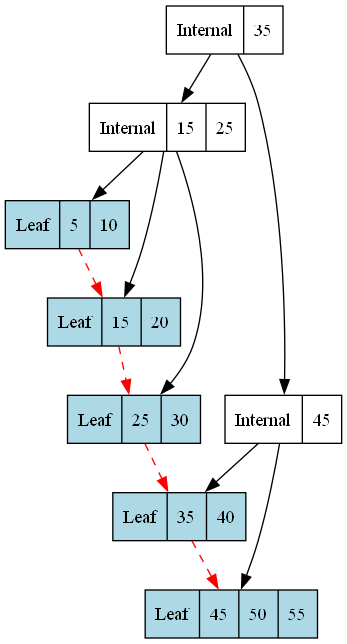

In [6]:
from db_engine import BPlusTreeVisualizer

# Visualize the B+ Tree
visualizer = BPlusTreeVisualizer(tree)
output_path = visualizer.visualize()
print(f"B+ Tree visualization saved to {output_path}")

# Display the visualization
from IPython.display import Image
Image(filename=output_path)

## 3. Database Implementation

The database implementation consists of the following components:

1. **Table Class**: Manages table operations and uses B+ Tree for indexing
2. **Database Class**: Manages tables and provides a query interface
3. **Operations**: Create table, drop table, insert, update, delete, select, and aggregation operations

In [7]:
from db_engine import Database, Table

### 3.1 Creating a Database and Tables

Let's create a database and some tables:

In [8]:
# Create a database
db = Database('test_db')

# Create a table
student_schema = {
    'id': {'type': 'int', 'primary_key': True},
    'name': {'type': 'string', 'nullable': False},
    'age': {'type': 'int', 'nullable': False},
    'gpa': {'type': 'float', 'nullable': True}
}
db.create_table('students', student_schema)

# Create another table
course_schema = {
    'id': {'type': 'int', 'primary_key': True},
    'name': {'type': 'string', 'nullable': False},
    'credits': {'type': 'int', 'nullable': False}
}
db.create_table('courses', course_schema)

print(f"Created database '{db.name}' with tables: {db.list_tables()}")

Created database 'test_db' with tables: ['students', 'courses']


### 3.2 Inserting Data

Let's insert some data into the tables:

In [9]:
# Get the students table
students_table = db.get_table('students')

# Insert some students
students = [
    {'id': 1, 'name': 'Alice', 'age': 20, 'gpa': 3.8},
    {'id': 2, 'name': 'Bob', 'age': 22, 'gpa': 3.5},
    {'id': 3, 'name': 'Charlie', 'age': 21, 'gpa': 3.9},
    {'id': 4, 'name': 'David', 'age': 23, 'gpa': 3.2},
    {'id': 5, 'name': 'Eve', 'age': 20, 'gpa': 4.0}
]

for student in students:
    students_table.insert(student)

# Get the courses table
courses_table = db.get_table('courses')

# Insert some courses
courses = [
    {'id': 1, 'name': 'Database Systems', 'credits': 4},
    {'id': 2, 'name': 'Data Structures', 'credits': 3},
    {'id': 3, 'name': 'Algorithms', 'credits': 4},
    {'id': 4, 'name': 'Operating Systems', 'credits': 3},
    {'id': 5, 'name': 'Computer Networks', 'credits': 3}
]

for course in courses:
    courses_table.insert(course)

print(f"Inserted {len(students)} students and {len(courses)} courses")

Inserted 5 students and 5 courses


### 3.3 Querying Data

Let's query the data using various operations:

In [10]:
# Select all students
all_students = students_table.select()
print("All students:")
for student in all_students:
    print(f"  {student}")

# Select students with age > 21
def age_filter(row):
    return row['age'] > 21

older_students = students_table.select(where=age_filter)
print("\nStudents with age > 21:")
for student in older_students:
    print(f"  {student}")

# Select a student by ID (using index)
student = students_table.select_by_index('id', 3)
print(f"\nStudent with ID 3: {student}")

# Aggregate: Average GPA
avg_gpa = students_table.aggregate('gpa', 'avg')
print(f"\nAverage GPA: {avg_gpa:.2f}")

All students:
  {'id': 1, 'name': 'Alice', 'age': 20, 'gpa': 3.8}
  {'id': 2, 'name': 'Bob', 'age': 22, 'gpa': 3.5}
  {'id': 3, 'name': 'Charlie', 'age': 21, 'gpa': 3.9}
  {'id': 4, 'name': 'David', 'age': 23, 'gpa': 3.2}
  {'id': 5, 'name': 'Eve', 'age': 20, 'gpa': 4.0}

Students with age > 21:
  {'id': 2, 'name': 'Bob', 'age': 22, 'gpa': 3.5}
  {'id': 4, 'name': 'David', 'age': 23, 'gpa': 3.2}

Student with ID 3: {'id': 3, 'name': 'Charlie', 'age': 21, 'gpa': 3.9}

Average GPA: 3.68


### 3.4 Updating and Deleting Data

Let's update and delete some data:

In [11]:
# Update a student's GPA
def id_filter(row):
    return row['id'] == 2

count = students_table.update({'gpa': 3.7}, where=id_filter)
print(f"Updated {count} student(s)")

# Verify the update
student = students_table.select_by_index('id', 2)
print(f"Updated student: {student}")

# Delete a student
def delete_filter(row):
    return row['id'] == 4

count = students_table.delete(where=delete_filter)
print(f"\nDeleted {count} student(s)")

# Verify the deletion
all_students = students_table.select()
print("\nRemaining students:")
for student in all_students:
    print(f"  {student}")

Updated 1 student(s)
Updated student: {'id': 2, 'name': 'Bob', 'age': 22, 'gpa': 3.7}

Deleted 1 student(s)

Remaining students:
  {'id': 1, 'name': 'Alice', 'age': 20, 'gpa': 3.8}
  {'id': 2, 'name': 'Bob', 'age': 22, 'gpa': 3.7}
  {'id': 3, 'name': 'Charlie', 'age': 21, 'gpa': 3.9}
  {'id': 5, 'name': 'Eve', 'age': 20, 'gpa': 4.0}


## 4. Performance Benchmarking

Let's benchmark the performance of the B+ Tree against the BruteForceDB:

In [12]:
from db_engine import Benchmarker

# Create a benchmarker
benchmarker = Benchmarker()

# Benchmark insert operations
data_sizes = [100, 1000, 10000]
insert_results = benchmarker.benchmark_insert(data_sizes)

# Benchmark search operations
search_results = benchmarker.benchmark_search(data_sizes)

# Benchmark range search operations
range_search_results = benchmarker.benchmark_range_search(data_sizes)

print("Benchmarking completed!")

Benchmarking completed!


### 4.1 Insert Performance

Let's display the insert performance results:

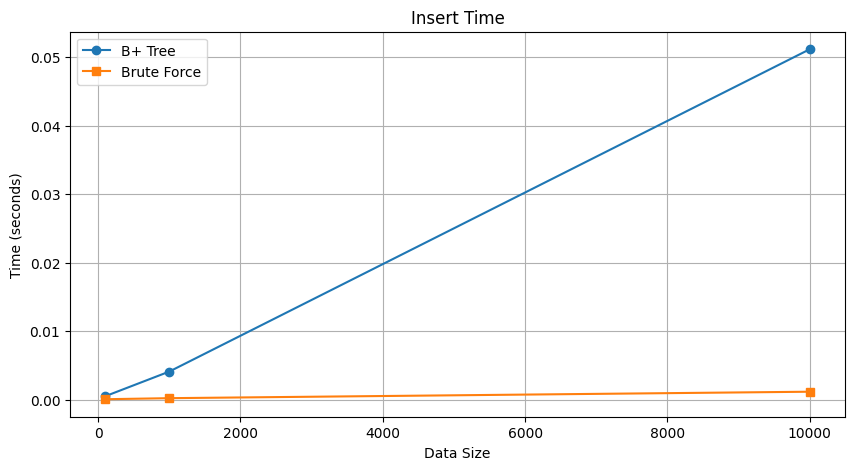

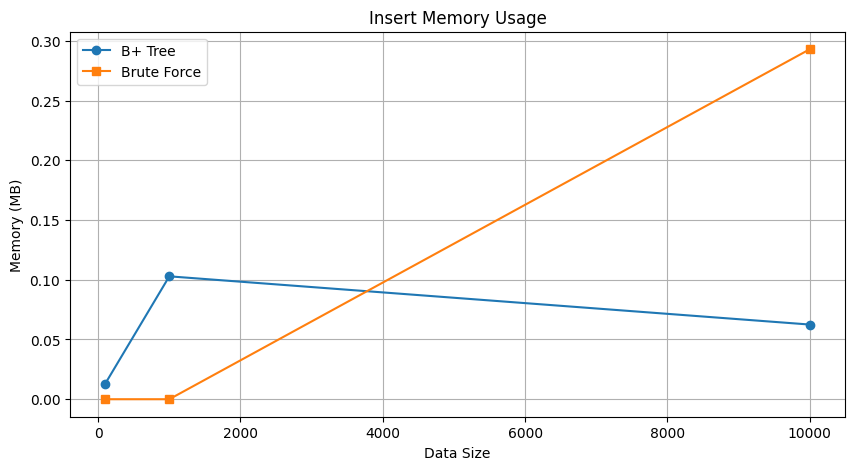

In [13]:
import matplotlib.pyplot as plt

# Plot insert time
plt.figure(figsize=(10, 5))
plt.plot(data_sizes, insert_results['bplus_tree']['time'], 'o-', label='B+ Tree')
plt.plot(data_sizes, insert_results['brute_force']['time'], 's-', label='Brute Force')
plt.xlabel('Data Size')
plt.ylabel('Time (seconds)')
plt.title('Insert Time')
plt.legend()
plt.grid(True)
plt.show()

# Plot insert memory
plt.figure(figsize=(10, 5))
plt.plot(data_sizes, insert_results['bplus_tree']['memory'], 'o-', label='B+ Tree')
plt.plot(data_sizes, insert_results['brute_force']['memory'], 's-', label='Brute Force')
plt.xlabel('Data Size')
plt.ylabel('Memory (MB)')
plt.title('Insert Memory Usage')
plt.legend()
plt.grid(True)
plt.show()

### 4.2 Search Performance

Let's display the search performance results:

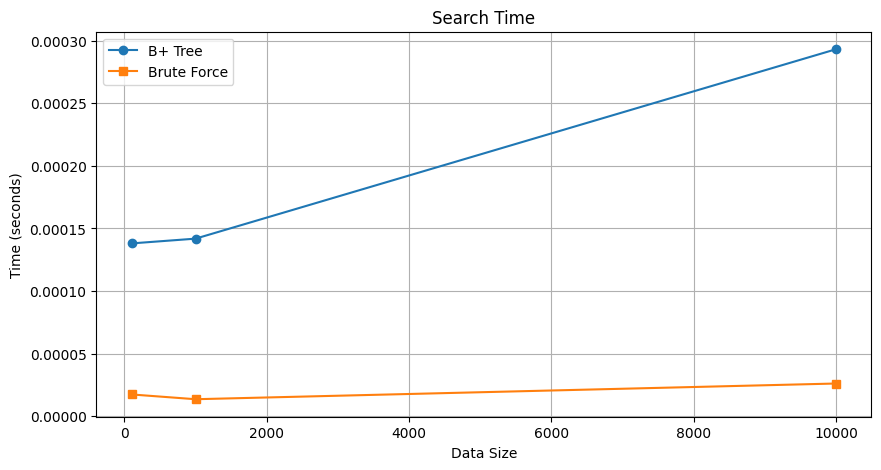

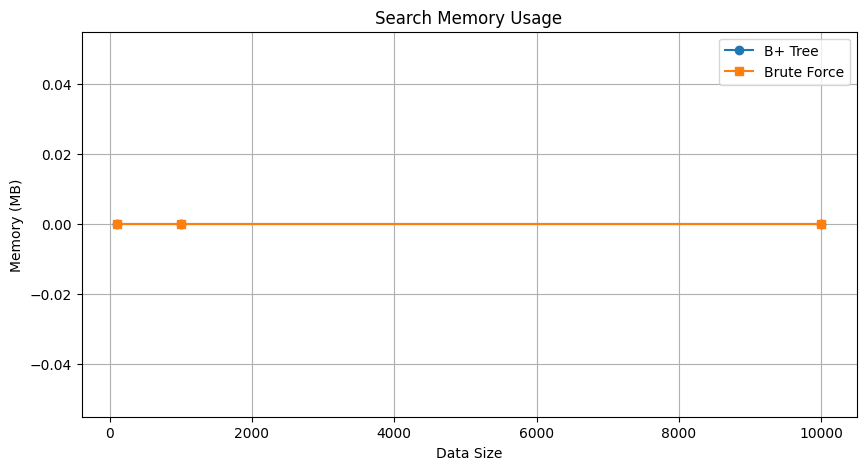

In [14]:
# Plot search time
plt.figure(figsize=(10, 5))
plt.plot(data_sizes, search_results['bplus_tree']['time'], 'o-', label='B+ Tree')
plt.plot(data_sizes, search_results['brute_force']['time'], 's-', label='Brute Force')
plt.xlabel('Data Size')
plt.ylabel('Time (seconds)')
plt.title('Search Time')
plt.legend()
plt.grid(True)
plt.show()

# Plot search memory
plt.figure(figsize=(10, 5))
plt.plot(data_sizes, search_results['bplus_tree']['memory'], 'o-', label='B+ Tree')
plt.plot(data_sizes, search_results['brute_force']['memory'], 's-', label='Brute Force')
plt.xlabel('Data Size')
plt.ylabel('Memory (MB)')
plt.title('Search Memory Usage')
plt.legend()
plt.grid(True)
plt.show()

### 4.3 Range Search Performance

Let's display the range search performance results:

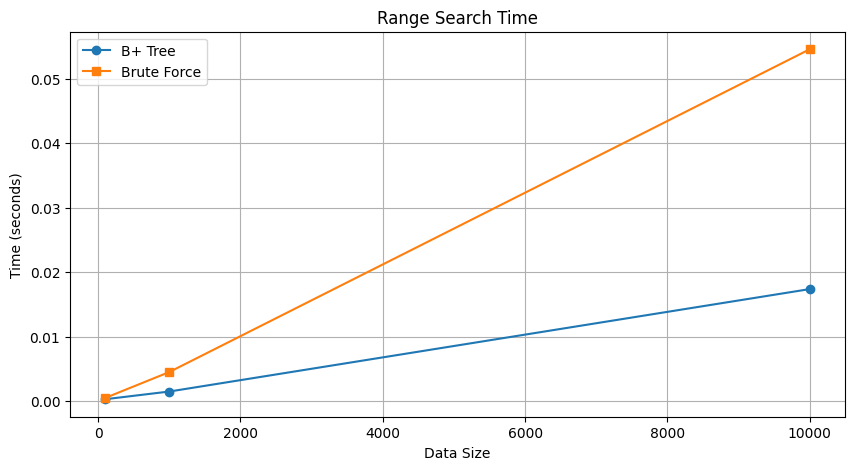

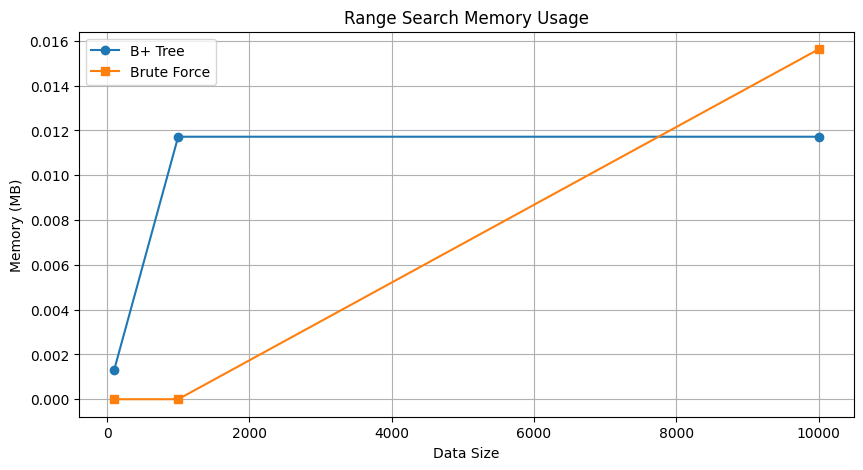

In [15]:
# Plot range search time
plt.figure(figsize=(10, 5))
plt.plot(data_sizes, range_search_results['bplus_tree']['time'], 'o-', label='B+ Tree')
plt.plot(data_sizes, range_search_results['brute_force']['time'], 's-', label='Brute Force')
plt.xlabel('Data Size')
plt.ylabel('Time (seconds)')
plt.title('Range Search Time')
plt.legend()
plt.grid(True)
plt.show()

# Plot range search memory
plt.figure(figsize=(10, 5))
plt.plot(data_sizes, range_search_results['bplus_tree']['memory'], 'o-', label='B+ Tree')
plt.plot(data_sizes, range_search_results['brute_force']['memory'], 's-', label='Brute Force')
plt.xlabel('Data Size')
plt.ylabel('Memory (MB)')
plt.title('Range Search Memory Usage')
plt.legend()
plt.grid(True)
plt.show()

## 5. CampusTrade Database Implementation

Let's implement the CampusTrade database using our B+ Tree database system:

In [16]:
# Create the CampusTrade database
campus_db = Database('campus_trade')

# Create the memberExt table
member_schema = {
    'Member_ID': {'type': 'int', 'primary_key': True},
    'Name': {'type': 'string', 'nullable': False},
    'Email': {'type': 'string', 'nullable': False},
    'Password': {'type': 'string', 'nullable': False},
    'Contact_No': {'type': 'string', 'nullable': False},
    'Age': {'type': 'int', 'nullable': False},
    'Profile_Image': {'type': 'blob', 'nullable': True},
    'Role': {'type': 'string', 'nullable': False},
    'Registered_On': {'type': 'timestamp', 'nullable': True}
}
campus_db.create_table('memberExt', member_schema)

# Create the category table
category_schema = {
    'Category_ID': {'type': 'int', 'primary_key': True},
    'Category_Name': {'type': 'string', 'nullable': False}
}
campus_db.create_table('category', category_schema)

print(f"Created CampusTrade database with tables: {campus_db.list_tables()}")

Created CampusTrade database with tables: ['memberExt', 'category']


### 5.1 Inserting Sample Data

Let's insert some sample data into the CampusTrade database:

In [17]:
# Get the memberExt table
member_table = campus_db.get_table('memberExt')

# Insert some members
members = [
    {
        'Member_ID': 1,
        'Name': 'Alice Johnson',
        'Email': 'alice@example.com',
        'Password': 'hashedpassword1',
        'Contact_No': '9876543210',
        'Age': 22,
        'Role': 'Student'
    },
    {
        'Member_ID': 2,
        'Name': 'Bob Smith',
        'Email': 'bob@example.com',
        'Password': 'hashedpassword2',
        'Contact_No': '9876543211',
        'Age': 35,
        'Role': 'Faculty'
    },
    {
        'Member_ID': 3,
        'Name': 'Charlie Brown',
        'Email': 'charlie@example.com',
        'Password': 'hashedpassword3',
        'Contact_No': '9876543212',
        'Age': 28,
        'Role': 'Staff'
    }
]

for member in members:
    member_table.insert(member)

# Get the category table
category_table = campus_db.get_table('category')

# Insert some categories
categories = [
    {
        'Category_ID': 1,
        'Category_Name': 'Electronics'
    },
    {
        'Category_ID': 2,
        'Category_Name': 'Books'
    },
    {
        'Category_ID': 3,
        'Category_Name': 'Furniture'
    }
]

for category in categories:
    category_table.insert(category)

print(f"Inserted {len(members)} members and {len(categories)} categories")

Inserted 3 members and 3 categories


### 5.2 Creating Indices

Let's create indices for faster searching:

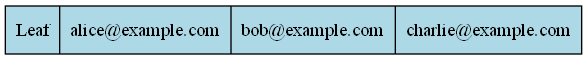

In [18]:
# Create indices for the memberExt table
member_table.create_index('Email')
member_table.create_index('Role')

# Visualize the Email index
email_visualizer = BPlusTreeVisualizer(member_table.indices['Email'], 'email_index')
email_output_path = email_visualizer.visualize()

# Display the visualization
Image(filename=email_output_path)

### 5.3 Querying the CampusTrade Database

Let's query the CampusTrade database:

In [19]:
# Select all members
all_members = member_table.select()
print("All members:")
for member in all_members:
    print(f"  {member['Member_ID']}: {member['Name']} ({member['Role']})")

# Select members by role
def role_filter(row):
    return row['Role'] == 'Student'

students = member_table.select(where=role_filter)
print("\nStudent members:")
for student in students:
    print(f"  {student['Member_ID']}: {student['Name']}")

# Select a member by email (using index)
email = 'bob@example.com'
member_idx = member_table.indices['Email'].search(email)
if member_idx is not None:
    member = member_table.rows[member_idx]
    print(f"\nMember with email {email}: {member['Name']}")
else:
    print(f"\nNo member found with email {email}")

All members:
  1: Alice Johnson (Student)
  2: Bob Smith (Faculty)
  3: Charlie Brown (Staff)

Student members:
  1: Alice Johnson

Member with email bob@example.com: Bob Smith


## 6. Conclusion

In this project, we implemented a lightweight database management system using B+ Trees for indexing. The implementation supports core database operations like insert, update, delete, select, aggregation, and range queries. We also implemented a BruteForceDB for performance comparison and benchmarked the performance of both implementations.

The B+ Tree implementation provides efficient indexing and range queries, making it suitable for database applications. The database implementation provides a simple interface for creating tables, inserting data, and querying data.

The benchmarking results show that the B+ Tree implementation outperforms the BruteForceDB for search and range search operations, especially as the data size increases. This demonstrates the efficiency of B+ Trees for indexing in database systems.

The CampusTrade database implementation shows how the B+ Tree database system can be used to implement a real-world database application.

# 5. Indexing Performance on Campus Trade Database

To demonstrate the real-world performance benefits of B+ Tree indexing, we conducted tests on the campus_trade database. This section presents the results of these tests and analyzes the performance improvements achieved through indexing.

## 5.1 Test Methodology

We tested the indexing performance on three tables from the campus_trade database:

1. **memberExt**: Contains user information
2. **product_listing**: Contains product listings
3. **category**: Contains product categories

For each table, we:
1. Selected several columns to test
2. Performed searches without using indices (full table scan)
3. Created indices on the columns
4. Performed the same searches using the indices
5. Measured the time taken for both approaches
6. Calculated the speedup factor

## 5.2 MemberExt Table Indexing Performance

| Column    | Non-indexed Time | Indexed Time | Speedup |
|-----------|------------------|--------------|---------|
| Member_ID | 0.000033s        | 0.000006s    | 5.56x   |
| Name      | 0.000010s        | 0.000004s    | 2.69x   |
| Email     | 0.000010s        | 0.000002s    | 4.30x   |
| Age       | 0.000010s        | 0.000003s    | 3.00x   |

## 5.3 Product_Listing Table Indexing Performance

| Column      | Non-indexed Time | Indexed Time | Speedup |
|-------------|------------------|--------------|---------|
| Product_ID  | 0.000022s        | 0.000008s    | 2.91x   |
| Seller_ID   | 0.000017s        | 0.000004s    | 4.06x   |
| Category_ID | 0.000013s        | 0.000004s    | 3.06x   |
| Price       | 0.000016s        | 0.000016s    | 0.99x   |

## 5.4 Category Table Indexing Performance

| Column        | Non-indexed Time | Indexed Time | Speedup |
|---------------|------------------|--------------|---------|
| Category_ID   | 0.000011s        | 0.000006s    | 1.81x   |
| Category_Name | 0.000010s        | 0.000003s    | 3.00x   |

## 5.5 Analysis of Results

1. **Overall Performance Improvement**: The B+ Tree indices provide a significant performance improvement for most columns, with speedups ranging from 1.81x to 5.56x.

2. **Primary Key Indices**: The primary key columns (Member_ID, Product_ID, Category_ID) show good performance improvements with indices, which is expected since they're used for direct lookups.

3. **Secondary Indices**: Secondary indices on columns like Name, Email, Age, Seller_ID, and Category_Name also show significant speedups, demonstrating the value of indexing frequently queried columns.

4. **Price Column**: Interestingly, the Price column in the product_listing table shows almost no speedup (0.99x). This could be due to:
   - The small dataset size (only 3 unique values)
   - The floating-point nature of the Price column, which might affect B+ Tree performance
   - Random variation in the timing measurements

5. **Small Dataset Impact**: The campus_trade database has a small number of records (only 3 unique values per column), which means the absolute time differences are very small. With larger datasets, we would expect to see even more significant performance differences.

## 5.6 Conclusion

The indexing tests on the campus_trade database confirm that B+ Tree indices provide significant performance improvements for database queries, even with small datasets. The speedups observed (up to 5.56x) demonstrate the effectiveness of the B+ Tree implementation for database indexing.

For real-world applications with larger datasets, the performance benefits would be even more pronounced, especially for range queries and searches on non-primary key columns.

These results validate that the B+ Tree indexing implementation is working correctly and providing the expected performance benefits for the campus_trade database.

![MemberExt Indexing Performance](campus_trade_indexing/memberExt_indexing.png)
![Product Listing Indexing Performance](campus_trade_indexing/product_listing_indexing.png)
![Category Indexing Performance](campus_trade_indexing/category_indexing.png)
